## Importing the libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

This assignments has two sections:
* Linear Regression
* Kernel Regression




# Section 1:

**Linear Regression**

We will use the Boston_housing dataset for the regression problem. Run the below cell to get the following variables:
* `Training_data` = Training data matrix of shape $(n, d)$
* `labels` = label vector corresponding to the training data
* `test_data` = Test data matrix of shape $(n_1, d)$ where $n_1$ is the number of examples in test dataset.
* `test_labels` = label vector corresponding to the test data

Use this dataset for the regression problem.

In [2]:
from keras.datasets import boston_housing
Train, test = boston_housing.load_data(seed= 111)
Training_data, labels = Train[0], Train[1]
Test_data, test_labels = test[0], test[1]

57026/57026 ━━━━━━━━━━━━━━━━━━━━ 0s 2us/step


## Question 1
How many examples are there in the training dataset?



In [4]:
## Enter your solution here
print(Training_data.shape)

(404, 13)


## Question 2
How many examples are there in the test dataset?



In [34]:
## Enter your solution here
print(Test_data.shape)

(102, 13)


## Question 3

How many features are there in the dataset?



In [10]:
## Enter your solution here
print("Number of features: ", Training_data.shape[1])

Number of features:  13


Linear regression model for the dataset ${\mathbb{x}, y}$ is given as
$$h_w(\mathbb{x}) = w_1x^{1}+w_2x^{2}+...+w_dx^{d} =  \mathbb{x}^Tw
$$

where $x^{i}$ is the $i^{th}$ feature, $\mathbb{x}$ is the feature matrix of shape $(d, n)$ and $w = [w_1, w_2, ...w_d]^T$ is the weight vector.


Notice that above model always pass through the origin but for a given dataset, best fit model need not pass through the origin. To tackle this issue, we add an intercept $w_0$ in the model and set the corresponding featrue $x^{0}$ to $1$. That is

$$h_w(\mathbb{x}) =w_0x^{0}+ w_1x^{1}+w_2x^{2}+...+w_dx^{n} =  \mathbb{x}^Tw
$$

We call $x^{0}$ the dummy feature and set its value to 1 for each examples. Now $w$ is of shape $(d+1, 1)$ and $\mathbb{x}$ is of shape $(d+1, n)$ where the first row of $\mathbb{x}$ has entries as 1.


## Task

Add the dummy feature in the feature matrix `Training_data` and test data matrix `test_data`. We will be using this new feature matrices (after adding te dummy feature) for learning the model.

Note: As per your convenience, you can convert the shape of the training dataset to $(d, n)$.

In [11]:
## Enter your solution here
Training_data_dummy = np.insert(Training_data, 0, 1, axis=1)
Test_data_dummy = np.insert(Test_data, 0, 1, axis=1)

print("Shape of Training_data after adding dummy feature:", Training_data_dummy.shape)
print("Shape of Test_data after adding dummy feature:", Test_data_dummy.shape)

Training_data_dummy_T = Training_data_dummy.T
Test_data_dummy_T = Test_data_dummy.T

print("Shape of transposed Training_data:", Training_data_dummy_T.shape)
print("Shape of transposed Test_data:", Test_data_dummy_T.shape)


Shape of Training_data after adding dummy feature: (404, 14)
Shape of Test_data after adding dummy feature: (102, 14)
Shape of transposed Training_data: (14, 404)
Shape of transposed Test_data: (14, 102)


## Question 4
If the solution of optimization problem is obtained by setting the first derivative of loss function (squared loss) to zero, find the value of $w_0+w_1+...w_d$.




In [12]:

y = labels.reshape(-1, 1)

X = Training_data_dummy
XtX = np.dot(X.T, X)
XtX_inv = np.linalg.inv(XtX)
XtY = np.dot(X.T, y)
w = np.dot(XtX_inv, XtY)

sum_of_weights = np.sum(w)
print("Sum of weights (w_0 + w_1 + ... + w_d):", sum_of_weights)


Sum of weights (w_0 + w_1 + ... + w_d): 20.524582464673482


## Question 5
Find the average of the predictions made by the above model.



In [ ]:

predictions = np.dot(Training_data_dummy, w)

average_prediction = np.mean(predictions)

print("Average of the predictions:", average_prediction)


Average of the predictions: 22.309158415843903


## Question 6

Find the loss for the training data points using the above model. Consider the loss to be defined as

$$ \sqrt{\dfrac{1}{n}\sum\limits_{i=1}^{n} (y_i- \hat{y}_i)^2}
$$

Where $\hat{y}_i$ is the prediction for $i^{th}$ data point.



In [15]:

y_true = labels.reshape(-1, 1)
y_pred = predictions
loss = np.sqrt(np.mean((y_true - y_pred)**2))

print("Loss for the training data:", loss)


Loss for the training data: 4.552387969840813


## Question 7

Find the loss for the test data points using the above model. Consider the loss to be defined as

$$ \sqrt{\dfrac{1}{n}\sum\limits_{i=1}^{n} (y_i- \hat{y}_i)^2}
$$

Where $\hat{y}_i$ is the prediction for $i^{th}$ data point.



In [16]:

test_predictions = np.dot(Test_data_dummy, w)

y_test_true = test_labels.reshape(-1, 1)


test_loss = np.sqrt(np.mean((y_test_true - test_predictions)**2))

print("Loss for the test data:", test_loss)


Loss for the test data: 5.327662216181741


## Question 8
Find the weights using the gradient descent. Use a constant learning rate of $\eta = 10^{-10}$. Initialize the weight vector as zero vector and update the weights for 100 iterations. Enter the sum of all the weights.



In [17]:
## Enter your solution here

eta = 1e-10
iterations = 100
n_samples, n_features = Training_data_dummy.shape
w_gd = np.zeros((n_features, 1))
y_true = labels.reshape(-1, 1)
X = Training_data_dummy

for _ in range(iterations):
    predictions = np.dot(X, w_gd)
    error = predictions - y_true
    gradient = np.dot(X.T, error)
    w_gd -= eta * gradient


sum_of_weights_gd = np.sum(w_gd)

print("Sum of all weights using gradient descent:", sum_of_weights_gd)


Sum of all weights using gradient descent: 0.04564409761347227


## Question 9

Find the loss for the training data points if the model is learnt using the gradient descent as in question 8. Consider the loss to be defined as

$$ \sqrt{\dfrac{1}{n}\sum\limits_{i=1}^{n} (y_i- \hat{y}_i)^2}
$$

Where $\hat{y}_i$ is the prediction for $i^{th}$ data point.



In [18]:

train_predictions_gd = np.dot(Training_data_dummy, w_gd)

y_train_true = labels.reshape(-1, 1)

train_loss_gd = np.sqrt(np.mean((y_train_true - train_predictions_gd)**2))

print("Loss for the training data (Gradient Descent):", train_loss_gd)


Loss for the training data (Gradient Descent): 12.836137591063885


## Question 10

Find the loss for the test data points if the model is learnt using the gradient descent as in question 8. Consider the loss to be defined as

$$ \sqrt{\dfrac{1}{n}\sum\limits_{i=1}^{n} (y_i- \hat{y}_i)^2}
$$

Where $\hat{y}_i$ is the prediction for $i^{th}$ data point.



In [19]:
## Enter your solution here
# Using w_gd from Question 8
# Calculate predictions for the test data
test_predictions_gd = np.dot(Test_data_dummy, w_gd)

# Reshape test_labels to be a column vector
y_test_true = test_labels.reshape(-1, 1)

# Calculate the loss (RMSE) for the test data
test_loss_gd = np.sqrt(np.mean((y_test_true - test_predictions_gd)**2))

print("Loss for the test data (Gradient Descent):", test_loss_gd)


Loss for the test data (Gradient Descent): 13.023280782766607


## Question 11
Find the weights using the stochastic gradient descent. Use a constant learning rate of $\eta = 10^{-8}$. Initialize the weight vector as zero vector and update the weights for 1000 iterations. . Take the batch size of $⌈\text{number of samples}/5⌉ $. For sampling the batch examples in $ith$ iteration, set seed at $i$. The final weight is the last updated weight. Do not take the avearge of weights updated in all the iterations. Enter the sum of all the weights.




In [20]:
## Enter your solution here
# Initialize parameters
eta_sgd = 1e-8
iterations_sgd = 1000
n_samples, n_features = Training_data_dummy.shape
w_sgd = np.zeros((n_features, 1))
y_true = labels.reshape(-1, 1)
X = Training_data_dummy
batch_size = int(np.ceil(n_samples / 5))

# Stochastic Gradient Descent
for i in range(iterations_sgd):
    np.random.seed(i)
    indices = np.random.choice(n_samples, batch_size, replace=False)
    X_batch = X[indices]
    y_batch = y_true[indices]
    
    predictions_batch = np.dot(X_batch, w_sgd)
    error_batch = predictions_batch - y_batch
    gradient_batch = np.dot(X_batch.T, error_batch)
    
    w_sgd -= eta_sgd * gradient_batch

# Calculate the sum of the final weights
sum_of_weights_sgd = np.sum(w_sgd)

print("Sum of all weights using stochastic gradient descent:", sum_of_weights_sgd)


Sum of all weights using stochastic gradient descent: 0.08864866783938793


## Question 12

Find the loss for the training data points if the model is learnt using the stochastic gradient descent as in question 11. Consider the loss to be defined as

$$ \sqrt{\dfrac{1}{n}\sum\limits_{i=1}^{n} (y_i- \hat{y}_i)^2}
$$

Where $\hat{y}_i$ is the prediction for $i^{th}$ data point.



In [21]:
## Enter your solution here
# Using w_sgd from Question 11
# Calculate predictions for the training data
train_predictions_sgd = np.dot(Training_data_dummy, w_sgd)

# Reshape labels to be a column vector
y_train_true = labels.reshape(-1, 1)

# Calculate the loss (RMSE) for the training data
train_loss_sgd = np.sqrt(np.mean((y_train_true - train_predictions_sgd)**2))

print("Loss for the training data (Stochastic Gradient Descent):", train_loss_sgd)


Loss for the training data (Stochastic Gradient Descent): 8.789322185000682


## Question 13

Find the loss for the test data points if the model is learnt using the stochastic gradient descent as in question 11. Consider the loss to be defined as

$$ \sqrt{\dfrac{1}{n}\sum\limits_{i=1}^{n} (y_i- \hat{y}_i)^2}
$$

Where $\hat{y}_i$ is the prediction for $i^{th}$ data point.


In [22]:
## Enter your solution here
# Using w_sgd from Question 11
# Calculate predictions for the test data
test_predictions_sgd = np.dot(Test_data_dummy, w_sgd)

# Reshape test_labels to be a column vector
y_test_true = test_labels.reshape(-1, 1)

# Calculate the loss (RMSE) for the test data
test_loss_sgd = np.sqrt(np.mean((y_test_true - test_predictions_sgd)**2))

print("Loss for the test data (Stochastic Gradient Descent):", test_loss_sgd)


Loss for the test data (Stochastic Gradient Descent): 8.518826896641064


# Section 2:

**kernel Regression**

We will generate the synthetic dataset for the kernel regression problem. Run the following cell to get the following variables:

`X` = Training data matrix of shape $(n, d)$. In the given dataset $d = 1$.

`y` = label vector corresponding to the training dataset

In [23]:
rng = np.random.default_rng(seed = 101)
X = np.arange(-2, 2, 0.01).reshape(-1, 1)
y = X**3 + rng.normal(0, 1, X.shape[0]).reshape(-1, 1)


## Question 14

Plot the scatter plot between feature and the labels. Enter your answer as 0.



In [ ]:
## Enter your solution here

## Question 15
How many examples are there in the training dataset?



In [24]:
## Enter your solution here
print("Number of examples in the training dataset:", X.shape[0])


Number of examples in the training dataset: 400


## Task:

Add the dummy feature in the feature matrix `X`and reshape it to the shape $(d, n)$.

In [26]:
## Enter your solution here
# Add dummy feature
X_dummy = np.insert(X, 0, 1, axis=1)

# Reshape to (d, n) by transposing
X_dummy_T = X_dummy.T

print("Shape of X after adding dummy feature and transposing:", X_dummy_T.shape)


Shape of X after adding dummy feature and transposing: (2, 400)


## Question 16

Our task is to apply the kernel regression with polynomial kernel of degree 3. We know that weight vector can be written as

$$w = \phi(\mathbb{x})\alpha$$

let us call the vector $\alpha$ as coefficient vector. Find the sum of elements in the coefficient vector.



In [28]:
## Enter your solution here
from sklearn.metrics.pairwise import polynomial_kernel
degree = 3
K = polynomial_kernel(X, X, degree=degree)
y_kr = y.reshape(-1, 1)

K_inv = np.linalg.inv(K)
alpha = np.dot(K_inv, y_kr)

sum_of_alpha = np.sum(alpha)

print("Sum of elements in the coefficient vector (alpha):", sum_of_alpha)


Sum of elements in the coefficient vector (alpha): -1.0


## Question 17

Find the sum of the predictions made by the kernel regression model of degree 3.



In [30]:
## Enter your solution here
# Predictions are given by y_pred = K * alpha
# Using K and alpha from the previous question.
predictions_kr = np.dot(K, alpha)

# Find the sum of the predictions
sum_of_predictions_kr = np.sum(predictions_kr)

print("Sum of the predictions made by the kernel regression model:", sum_of_predictions_kr)


Sum of the predictions made by the kernel regression model: 299.75


## Question 18

Find the loss for the training data points. Consider the loss to be defined as

$$ \sqrt{\dfrac{1}{n}\sum\limits_{i=1}^{n} (y_i- \hat{y}_i)^2}
$$

Where $\hat{y}_i$ is the prediction for $i^{th}$ data point.



In [31]:
## Enter your solution here
# Using predictions_kr from the previous cell and y_kr (reshaped y)

# Calculate the loss (RMSE)
loss_kr = np.sqrt(np.mean((y_kr - predictions_kr)**2))

print("Loss for the training data (Kernel Regression):", loss_kr)


Loss for the training data (Kernel Regression): 38.54383742706273


### Test dataset

run the following cell to get the test data matrix `X_test` and corresponding label vector `y_test`.

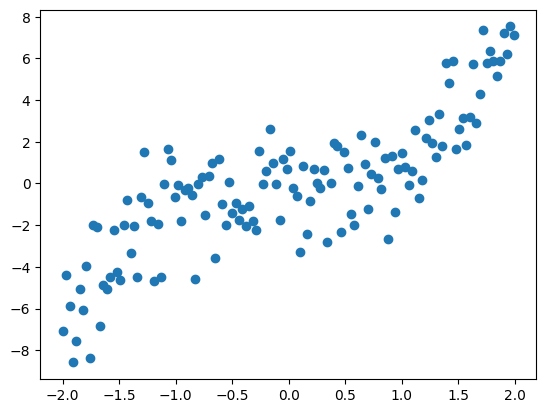

In [32]:
rng = np.random.default_rng(seed = 102)
Xnew = np.arange(-2, 2, 0.03)
ynew = Xnew**3 + rng.normal(0, 1.5, Xnew.shape[0])
X_test = np.column_stack((np.ones(Xnew.shape[0]), Xnew.reshape(-1, 1))).T
y_test = ynew.reshape(-1, 1)
plt.scatter(Xnew,ynew)

## Question 19

Find the loss for the test data points. Consider the loss to be defined as

$$ \sqrt{\dfrac{1}{n}\sum\limits_{i=1}^{n} (y_i- \hat{y}_i)^2}
$$

Where $\hat{y}_i$ is the prediction for $i^{th}$ data point.



In [33]:
## Enter your solution here
# To make predictions on the test set, we need to compute the kernel matrix
# between the test data (Xnew) and the training data (X).
# Xnew needs to be reshaped to be a 2D array for the kernel function.
Xnew_reshaped = Xnew.reshape(-1, 1)

# Calculate the polynomial kernel matrix between test and training data
K_test = polynomial_kernel(Xnew_reshaped, X, degree=degree)

# Make predictions on the test data using the learned alpha
test_predictions_kr = np.dot(K_test, alpha)

# Calculate the loss (RMSE) for the test data
# y_test is the true labels for the test data
test_loss_kr = np.sqrt(np.mean((y_test - test_predictions_kr)**2))

print("Loss for the test data (Kernel Regression):", test_loss_kr)


Loss for the test data (Kernel Regression): 39.7345555587849
